In [63]:
import os
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from pydantic import BaseModel, Field

In [64]:
load_dotenv()

True

In [65]:
model = ChatOpenAI(
    model=os.getenv("GEMINI_AI_MODEL"),
    api_key=os.getenv("GEMINI_API_KEY"),
    base_url="https://generativelanguage.googleapis.com/v1beta/openai/",
    temperature=0
)

In [66]:
class EvaluationOutput(BaseModel):
    evaluation_summary: str = Field(description="Brief explanation of the evaluation")
    score: int = Field(ge=0, le=10, description="Score between 0 and 10")

In [67]:
class EssayState(TypedDict):
    essay_text: str
    language_score: int
    structure_score: int
    factual_accuracy_score: int
    evaluation_summary: str 

In [68]:
structured_model = model.with_structured_output(EvaluationOutput)

In [69]:
def evaluate_essay_language(state: EssayState):
    prompt = f"Evaluate the language quality of the following essay and provide a score between 0 and 10:\n\n{state['essay_text']}"
    result = structured_model.invoke(prompt)
    return {
        "language_score": result.score
    }

In [70]:
def evaluate_essay_structure(state: EssayState):
    prompt = f"Evaluate the overall structure quality of the following essay and provide a score between 0 and 10:\n\n{state['essay_text']}"
    result = structured_model.invoke(prompt)
    return {
        "structure_score": result.score
    }

In [71]:
def evaluate_essay_factual_accuracy(state: EssayState):
    prompt = f"Evaluate the factual accuracy of the following essay and provide a score between 0 and 10:\n\n{state['essay_text']}"
    result = structured_model.invoke(prompt)
    return {
        "factual_accuracy_score": result
    }

In [72]:
def evaluate_essay_final(state: EssayState):
    prompt = f"Evaluate the essay and provide a detailed summary:\n\n Essay Text:{state['essay_text']}\n Language Score: {state['language_score']}\n Structure Score: {state['structure_score']}\n Factual Accuracy Score: {state['factual_accuracy_score']}"
    result = model.invoke(prompt)
    return {
        "evaluation_summary": result
    }

In [73]:
graph = StateGraph(EssayState)

graph.add_node("evaluate_essay_language", evaluate_essay_language)
graph.add_node("evaluate_essay_structure", evaluate_essay_structure)
graph.add_node("evaluate_essay_factual_accuracy", evaluate_essay_factual_accuracy)
graph.add_node("evaluate_essay_final", evaluate_essay_final)

graph.add_edge(START, "evaluate_essay_language")
graph.add_edge(START, "evaluate_essay_structure")
graph.add_edge(START, "evaluate_essay_factual_accuracy")

graph.add_edge("evaluate_essay_language","evaluate_essay_final")
graph.add_edge("evaluate_essay_structure","evaluate_essay_final")
graph.add_edge("evaluate_essay_factual_accuracy","evaluate_essay_final")

graph.add_edge("evaluate_essay_final", END)

workflow = graph.compile()

In [75]:
input = {"essay_text": "Cricket is a globally popular 11-player sport that originated in 16th-century England and is now governed by the ICC. Played on an open field centered around a 22-yard pitch, the game begins with a coin toss, after which the batting team aims to score runs while the fielding team works to dismiss them. The sport features three main international formats: traditional five-day Test matches, 50-over One Day Internationals (ODIs), and fast-paced 20-over Twenty20 (T20) games. Beyond the competition, cricket serves as a powerful unifying force that promotes teamwork, strategic thinking, and physical discipline worldwide."}
output = workflow.invoke(input)
print(output['evaluation_summary'])

content="## Essay Evaluation:\n\nThis essay provides an exceptionally clear, concise, and accurate overview of cricket. It effectively distills the core elements of the sport into a single, well-structured paragraph, making it highly accessible even to those unfamiliar with the game.\n\n**Language Score: 9**\nThe language used is precise, professional, and highly effective. The vocabulary is appropriate and varied, avoiding repetition while maintaining clarity. Sentences are well-constructed, grammatically sound, and flow smoothly, contributing to the essay's overall readability. There are no ambiguities or awkward phrasings, demonstrating a strong command of written English.\n\n**Structure Score: 9**\nDespite its brevity, the essay exhibits excellent structural integrity. It begins with a strong introductory statement, then logically progresses through the sport's origins, governing body, basic gameplay mechanics, key international formats, and concludes with its broader cultural impa

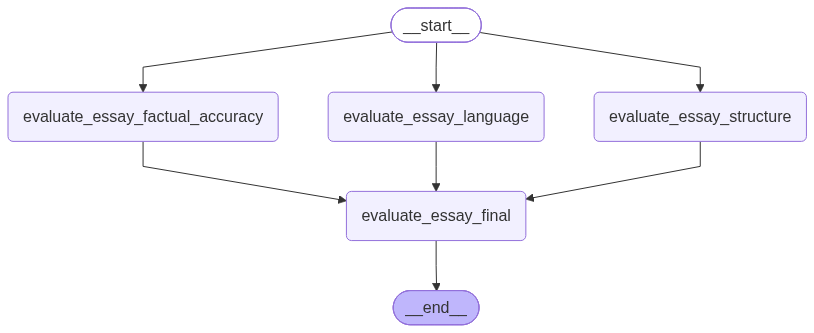

In [76]:
from IPython.display import display, Image

display(
    Image(workflow.get_graph().draw_mermaid_png())
)